In [10]:
# !pip uninstall -y flax orbax-checkpoint jax jaxlib \
#     ml-dtypes tf-keras tensorflow tensorflow-cpu tensorflow-text \
#     tensorflow-decision-forests keras keras-hub \
#     chex optax fastai spacy tensorstore numba \
#     umap-learn pynndescent librosa shap cuml-cu12 cudf-cu12 dask-cuda

%pip install -U threadpoolctl joblib
#%pip install --force-reinstall numpy==1.26.4
%pip install --upgrade scikit-learn
%pip install -U imbalanced-learn umap-learn

%pip install --upgrade --force-reinstall \
    numpy \
    scipy \
    matplotlib \
    seaborn \
    pandas \
    tensorflow

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 7.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.8/28.8 MB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [umap-learn]4 [numba]
Note: you may need to restart the kernel to use updated packages.
  Using cached numpy-2.0.2-cp39-cp39-macosx_14_0_arm64.whl.metadata (60 kB)
  Using cached scipy-1.13.1-cp39-cp39-macosx_12_0_arm64.whl.metadata (60 kB)
  Using cached matplotlib-3.9.4-cp39-cp39-macosx_11_0_arm64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached pandas-2.2.3-cp39-cp39-macosx_11_0_arm64.whl.metadata (89 kB)
  Using cached tensorflow-2.19.0-cp39-cp39-macosx_12_0_arm64.whl.metadata (4.0 kB)
  Using cached contourpy-1.3.0-cp39-cp39-macosx_11_0_arm64.whl.metadata (5.4 kB)
  Using cached cycl

In [3]:
import importlib, random, os, numpy as np, tensorflow as tf

print("===== VERSIONS =====")
for lib in ("numpy", "pandas", "sklearn", "imblearn",
            "tensorflow", "matplotlib", "seaborn"):
    m = importlib.import_module(lib if lib != "sklearn" else "sklearn")
    print(f"{lib:17s}: {m.__version__}")

print("\n===== TensorFlow devices =====")
print(tf.config.list_physical_devices())   # ← здесь будет только CPU, и это нормально

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
print(f"\nRandom seed set to {SEED}")

===== VERSIONS =====
numpy            : 1.24.3
pandas           : 2.0.3
sklearn          : 1.3.2
imblearn         : 0.12.4
tensorflow       : 2.13.0
matplotlib       : 3.7.5
seaborn          : 0.13.2

===== TensorFlow devices =====
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

Random seed set to 42


In [7]:
# === @title Этап 2 (Kaggle API) — Ethereum Fraud Detection ===
# 0. (если делали раньше, шаги с pip и токеном можно пропустить)

# — 0.1 Установка библиотеки kaggle —
%pip install --quiet kaggle

# # — 0.2 Загрузка kaggle.json (один раз за сессию Colab) —
# #    Если токен уже лежит в ~/.kaggle, эту строку можно пропустить.
# from google.colab import files, auth
# import pathlib, io, os, json, pandas as pd

# if not pathlib.Path("~/.kaggle/kaggle.json").expanduser().exists():
#     print("📂 Загрузите kaggle.json ➜")
#     token_file = files.upload()           # откроется диалог
#     if "kaggle.json" not in token_file:
#         raise ValueError("Нужно загрузить файл под именем kaggle.json")
#     pathlib.Path("~/.kaggle").expanduser().mkdir(exist_ok=True)
#     with open(pathlib.Path("~/.kaggle/kaggle.json").expanduser(), "wb") as f:
#         f.write(token_file["kaggle.json"])
#     !chmod 600 ~/.kaggle/kaggle.json
# else:
#     print("🔑 kaggle.json уже настроен")

import os
import json
import pathlib
import pandas as pd
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

# 1. Убедимся, что у нас есть файл kaggle.json (с токеном Kaggle)
kaggle_json_path = '../kaggle.json'

if not os.path.exists(kaggle_json_path):
    raise FileNotFoundError("Файл 'kaggle.json' не найден. Пожалуйста, скачайте его с вашего аккаунта Kaggle.")

# 2. Конфигурируем API Kaggle с использованием токена
with open(kaggle_json_path) as f:
    kaggle_json = json.load(f)

os.environ['KAGGLE_USERNAME'] = kaggle_json['username']
os.environ['KAGGLE_KEY'] = kaggle_json['key']

# 3. Инициализируем API
api = KaggleApi()
api.authenticate()

# 1. Скачиваем архив датасета
slug = "vagifa/ethereum-frauddetection-dataset"
print(f"\n⬇️ Скачиваю датасет {slug} ...")
!kaggle datasets download -d {slug} -p ./data --force --quiet

# 2. Распаковываем
print("📦 Распаковываю ...")
!unzip -o ./data/*.zip -d ./data > /dev/null

# 3. Открываем transactions.csv
csv_path = "./data/transactions.csv"
if not os.path.exists(csv_path):
    # fallback: берем первый найденный CSV
    import glob
    found = glob.glob("./data/**/*.csv", recursive=True)
    if not found:
        raise RuntimeError("CSV-файлы не найдены в архиве.")
    csv_path = found[0]
print(f"✅ Нашёл CSV: {csv_path}")

df = pd.read_csv(csv_path)

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)            # ожидаем (9840, 49)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")

Note: you may need to restart the kernel to use updated packages.

⬇️ Скачиваю датасет vagifa/ethereum-frauddetection-dataset ...
Dataset URL: https://www.kaggle.com/datasets/vagifa/ethereum-frauddetection-dataset
License(s): DbCL-1.0
  0%|                                                | 0.00/923k [00:00<?, ?B/s]
100%|████████████████████████████████████████| 923k/923k [00:00<00:00, 1.88GB/s]
📦 Распаковываю ...
✅ Нашёл CSV: ./data/transaction_dataset.csv

===== SHAPE =====
(9841, 51)

===== HEAD (5 строк) =====


,Unnamed: 0,Index,Address,FLAG,Avg min between sent tnx,Avg min between received tnx,Time Diff between first and last (Mins),Sent tnx,Received Tnx,Number of Created Contracts,...,ERC20 min val sent,ERC20 max val sent,ERC20 avg val sent,ERC20 min val sent contract,ERC20 max val sent contract,ERC20 avg val sent contract,ERC20 uniq sent token name,ERC20 uniq rec token name,ERC20 most sent token type,ERC20_most_rec_token_type
0,0,1,0x00009277775ac7d0d59eaad8fee3d10ac6c805e8,0,844.26,1093.71,704785.63,721,89,0,...,0.000000,1.683100e+07,271779.920000,0.0,0.0,0.0,39.0,57.0,Cofoundit,Numeraire
1,1,2,0x0002b44ddb1476db43c868bd494422ee4c136fed,0,12709.07,2958.44,1218216.73,94,8,0,...,2.260809,2.260809e+00,2.260809,0.0,0.0,0.0,1.0,7.0,Livepeer Token,Livepeer Token
2,2,3,0x0002bda54cb772d040f779e88eb453cac0daa244,0,246194.54,2434.02,516729.30,2,10,0,...,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,8.0,NaN,XENON
3,3,4,0x00038e6ba2fd5c09aedb96697c8d7b8fa6632e5e,0,10219.60,15785.09,397555.90,25,9,0,...,100.000000,9.029231e+03,3804.076893,0.0,0.0,0.0,1.0,11.0,Raiden,XENON
4,4,5,0x00062d1dd1afb6fb02540ddad9cdebfe568e0d89,0,36.61,10707.77,382472.42,4598,20,1,...,0.000000,4.500000e+04,13726.659220,0.0,0.0,0.0,6.0,27.0,StatusNetwork,EOS



===== Классовое соотношение (isFraud) =====


FLAG
0    77.86
1    22.14
Name: %, dtype: float64

In [48]:
import pandas as pd
df = pd.read_csv('../dataset/lstm/lstm_sequence.csv')

# 4. Отладочная информация
print("\n===== SHAPE =====")
print(df.shape)

print("\n===== HEAD (5 строк) =====")
display(df.head())

print("\n===== Классовое соотношение (isFraud) =====")
if "FLAG" in df.columns:
    display((df["FLAG"].value_counts(normalize=True) * 100).round(2).rename("%"))
else:
    print("Столбец 'FLAG' не найден — проверьте структуру датасета.")


===== SHAPE =====
(1106250, 42)

===== HEAD (5 строк) =====


,address,FLAG,FLAG_NUM,is_contract,scam_type,step_idx,window_start,Sent_tnx,Received_tnx,Number_of_Created_Contracts,...,ERC20_Total_Ether_Sent_Contract,ERC20_Uniq_Sent_Addr,ERC20_Uniq_Rec_Addr,ERC20_Uniq_Rec_Contract_Addr,ERC20_Min_Val_Rec,ERC20_Max_Val_Rec,ERC20_Avg_Val_Rec,ERC20_Min_Val_Sent,ERC20_Max_Val_Sent,ERC20_Avg_Val_Sent
0,0x000000000000000000000000000000000000dead,legit,0,False,NaN,0,2024-06-06,0,2722,0,...,202.395119,1,141,0,0.000366,7.320031e+11,6.944587e+09,0.0,168.304750,16.866260
1,0x000000000000000000000000000000000000dead,legit,0,False,NaN,1,2024-06-13,0,2869,0,...,163.546816,1,149,0,0.000000,4.192872e+06,5.715577e+04,0.0,63.426462,10.903121
2,0x000000000000000000000000000000000000dead,legit,0,False,NaN,2,2024-06-20,0,2678,0,...,28.318465,1,109,0,0.000181,1.672513e+11,1.276521e+09,0.0,11.172365,1.887898
3,0x000000000000000000000000000000000000dead,legit,0,False,NaN,3,2024-06-27,0,897,0,...,14.629905,1,193,0,0.000000,1.153366e+20,3.661481e+17,0.0,6.689017,0.975327
4,0x000000000000000000000000000000000000dead,legit,0,False,NaN,4,2024-07-04,0,534,0,...,43.688410,1,285,0,0.005390,1.000000e+13,2.618614e+11,0.0,39.818394,2.912561



===== Классовое соотношение (isFraud) =====


FLAG
legit      78.99
scam       20.52
suspect     0.49
Name: %, dtype: float64

In [49]:
import pandas as pd

# Загрузка датасета
df = pd.read_csv('../dataset/lstm/lstm_sequence.csv')

df = df[df['FLAG'] != "suspect"]
df['FLAG'] = df['FLAG'].map({'scam': 1, 'legit': 0})
df = df[df['is_contract']==False]

print(df.shape)


(483480, 42)


In [50]:
df.drop(columns=["Unnamed: 0", "Index", "FLAG_NUM", "is_contract", "scam_type"], inplace=True, errors="ignore")
df['FLAG'].value_counts(normalize=True)

FLAG
0    0.581658
1    0.418342
Name: proportion, dtype: float64

==> Shape после удаления служебных колонок: (483480, 39)

===== ТОП-10 столбцов по числу NaN =====


ERC20_Avg_Val_Rec               482681
ERC20_Max_Val_Rec               482681
ERC20_Min_Val_Rec               482681
ERC20_Avg_Val_Sent              482569
ERC20_Max_Val_Sent              482569
ERC20_Min_Val_Sent              482569
Avg_min_between_received_tnx    482112
Max_Value_Received              482111
Min_Value_Received              482111
Avg_Value_Received              482111
dtype: int64

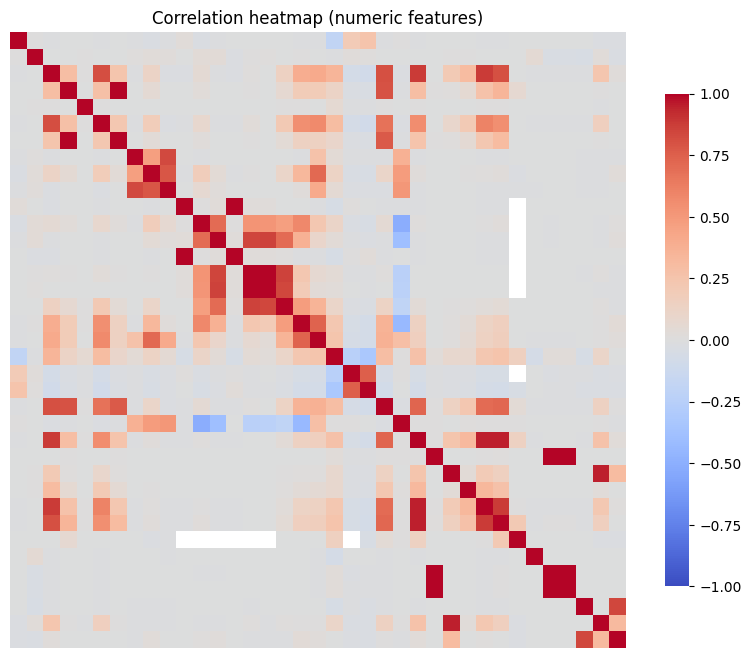


===== Признаки с нулевой дисперсией (n=0) =====
[]

===== Распределение FLAG =====


FLAG
0    58.17
1    41.83
Name: %, dtype: float64

In [51]:
# === @title Этап 3: первичный анализ и инвентаризация признаков ===
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# 0) Копируем исходный df (на всякий случай)
df_eda = df.copy()

# 1) Удаляем служебные колонки, если есть
svc_cols = ["Unnamed: 0", "Index"]
df_eda.drop(columns=[c for c in svc_cols if c in df_eda.columns],
            inplace=True, errors="ignore")

print("==> Shape после удаления служебных колонок:", df_eda.shape)

# 2) Проверяем пропуски
na_counts = df_eda.isna().sum()
na_nonzero = na_counts[na_counts > 0].sort_values(ascending=False)

print("\n===== ТОП-10 столбцов по числу NaN =====")
display(na_nonzero.head(10))

# 3) Корреляционная матрица Пирсона
num_cols = df_eda.select_dtypes(include=[np.number]).columns.tolist()
corr = df_eda[num_cols].corr(method="pearson")

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0,
            vmax=1, vmin=-1, square=True,
            cbar_kws={"shrink": .8}, xticklabels=False, yticklabels=False)
plt.title("Correlation heatmap (numeric features)")
plt.show()

# 4) Признаки с нулевой дисперсией (постоянные значения)
zero_var = df_eda[num_cols].loc[:, df_eda[num_cols].nunique() == 1].columns.tolist()
print(f"\n===== Признаки с нулевой дисперсией (n={len(zero_var)}) =====")
print(zero_var)

# 5) Быстрый взгляд на распределение классов (FLAG)
print("\n===== Распределение FLAG =====")
display(df_eda["FLAG"].value_counts(normalize=True).rename("%").mul(100).round(2))

In [52]:
# import pandas as pd

# # Группы по классу
# df_flag_1 = df[df['FLAG'] == 1]
# df_flag_0 = df[df['FLAG'] == 0]

# # Определим минимальное количество между классами
# min_class_count = min(len(df_flag_1), len(df_flag_0))

# # Случайная выборка из каждого класса
# df_flag_1_sampled = df_flag_1.sample(n=min_class_count, random_state=42)
# df_flag_0_sampled = df_flag_0.sample(n=int(min_class_count), random_state=42)

# # Объединяем и перемешиваем
# df_balanced = pd.concat([df_flag_1_sampled, df_flag_0_sampled], ignore_index=True)
# df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# # Проверим баланс классов
# print(df_balanced['FLAG'].value_counts())

# # Обновляем переменную df
# df = df_balanced


In [53]:
# === Этап 4: очистка признаков перед обучением ===
import pandas as pd, numpy as np

df_clean = df.copy()
df_clean.columns = df_clean.columns.str.strip()
df_clean.drop(columns=["Unnamed: 0", "Index"], inplace=True, errors="ignore")

# ---------------------------------------------------------------------
# 1. Выносим meta-колонки, которые нужны дальше для сплита/последовательностей
# ---------------------------------------------------------------------
meta_cols = ["address", "FLAG", "step_idx"]
df_meta   = df_clean[meta_cols].copy()          # здесь строки, даты и т.-д.
df_feat   = df_clean.drop(columns=meta_cols)    # только «сырые» признаки

# ---------------------------------------------------------------------
# 2. Удаляем object-признаки, которые НЕ нужны для модели
#    (остальные уже в df_meta)
# ---------------------------------------------------------------------
obj_to_drop = df_feat.select_dtypes(include="object").columns.tolist()
df_feat.drop(columns=obj_to_drop, inplace=True)

# ---------------------------------------------------------------------
# 3. Zero-variance
# ---------------------------------------------------------------------
to_drop = [c for c in zero_var if c in df_feat.columns]
df_feat.drop(columns=to_drop, inplace=True)

# ---------------------------------------------------------------------
# 4. Всё, что осталось, гарантированно переводим в numeric
#    и заливаем NaN медианой
# ---------------------------------------------------------------------
df_feat = df_feat.apply(pd.to_numeric, errors="coerce")
df_feat = df_feat.fillna(df_feat.median(numeric_only=True))

# 2) Проверяем пропуски
na_counts = df_feat.isna().sum()
na_nonzero = na_counts[na_counts > 0].sort_values(ascending=False)

print("\n===== ТОП-10 столбцов по числу NaN =====")
display(na_nonzero.head(10))

# ---------------------------------------------------------------------
# 5. Убираем сильно коррелирующие признаки
# ---------------------------------------------------------------------
corr   = df_feat.corr().abs()
upper  = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_drop = [c for c in upper.columns if any(upper[c] > 0.9)]
df_feat.drop(columns=high_corr_drop, inplace=True)

# ---------------------------------------------------------------------
# 6. Склеиваем обратно: meta + очищенные фичи
# ---------------------------------------------------------------------
df_clean = pd.concat([df_meta.reset_index(drop=True),
                      df_feat.reset_index(drop=True)], axis=1)


print("Итоговая форма df_clean:", df_clean.shape)



===== ТОП-10 столбцов по числу NaN =====


Series([], dtype: int64)

Итоговая форма df_clean: (483480, 31)


In [54]:
# === @title Этап 5: разделение и SMOTE ===
import numpy as np
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import MinMaxScaler
# === Этап 5: разделение и SMOTE ===
from sklearn.model_selection import train_test_split

SEED = 42

# 1. метка на один адрес
addr_flag = (
    df_clean.groupby('address')['FLAG']
            .first()                # берём первую (она же единственная) метку
)

unique_addr = addr_flag.index.values     # X для split
addr_flag   = addr_flag.values           # y для stratify ― длины совпадают!

# 2. train / test
train_addr, test_addr = train_test_split(
    unique_addr,
    test_size=0.20,
    random_state=SEED,
    stratify=addr_flag
)

# 3. train → train / val (опять стратифицируем по меткам адресов)
train_flag = df_clean.groupby('address')['FLAG'].first().loc[train_addr].values

train_addr, val_addr = train_test_split(
    train_addr,
    test_size=0.25,            # 0.25 от train = 0.20×0.25 = 0.05 от всего
    random_state=SEED,
    stratify=train_flag
)

# 4. собираем датафреймы
df_train = df_clean[df_clean['address'].isin(train_addr)].copy()
df_val   = df_clean[df_clean['address'].isin(val_addr)].copy()
df_test  = df_clean[df_clean['address'].isin(test_addr)].copy()


scaler = MinMaxScaler()
scaler.fit(df_train.drop(columns=['FLAG','address','step_idx']))

def scale(df):
    X = df.drop(columns=['FLAG','address','step_idx'])
    df_scaled = pd.DataFrame(
        scaler.transform(X), 
        columns=X.columns, index=df.index
    )
    df_scaled[['FLAG','address','step_idx']] = df[['FLAG','address','step_idx']]
    return df_scaled

df_train_s = scale(df_train)
df_val_s   = scale(df_val)
df_test_s  = scale(df_test)

SEQ_LEN = 25

def make_sequences(df, seq_len=SEQ_LEN):
    X_seq, y_seq = [], []
    # сортируем, чтобы шаги шли по возрастанию
    for _, g in df.sort_values(['address','step_idx']).groupby('address'):
        g_feat = g.drop(columns=['FLAG','address','step_idx']).values
        g_y    = g['FLAG'].values           # метка одинакова для всех step'ов
        for i in range(len(g) - seq_len + 1):
            X_seq.append(g_feat[i:i+seq_len])
            y_seq.append(g_y[i+seq_len-1])  # берём метку последнего шага
    return np.asarray(X_seq), np.asarray(y_seq)

X_train_lstm, y_train_lstm = make_sequences(df_train_s)
X_val_lstm,   y_val_lstm   = make_sequences(df_val_s)
X_test_lstm,  y_test_lstm  = make_sequences(df_test_s)

print('X_train_lstm shape:', X_train_lstm.shape)  # (n_seq, 10, n_features)


X_train_lstm shape: (58014, 25, 28)


In [55]:
# import pandas as pd
# from imblearn.over_sampling import SMOTE
# from sklearn.decomposition import PCA
# import umap
# import matplotlib.pyplot as plt

# # 1. Получаем X_train_res, y_train_res
# sm = SMOTE(random_state=42)
# X_res, y_res = sm.fit_resample(X_train, y_train)

# # 2. Помечаем, какие точки синтетические
# is_synth = ['real'] * len(X_train) + ['synthetic'] * (len(X_res) - len(X_train))
# df_vis = pd.DataFrame(X_res)
# df_vis['label'] = y_res
# df_vis['type']  = is_synth
# import numpy as np

# X_raw = df_vis.drop(columns=['label','type'])
# cols_inf = [c for c in X_raw.columns if np.isinf(X_raw[c]).any()]
# print("Есть inf в столбцах:", cols_inf)
# X_clean = X_raw.replace([np.inf, -np.inf], np.nan)
# X_clean = X_clean.fillna(X_clean.median())

# from sklearn.preprocessing import MinMaxScaler

# scaler = MinMaxScaler()
# X_scaled = scaler.fit_transform(X_clean)


# # 3. UMAP в 2D
# reducer = umap.UMAP(n_components=2, random_state=42)
# emb = reducer.fit_transform(X_scaled)

# # 4. Рисуем
# plt.figure(figsize=(8,6))
# for t, m in [('real','o'), ('synthetic','x')]:
#     idx = df_vis['type']==t
#     plt.scatter(emb[idx,0], emb[idx,1],
#                 c=df_vis.loc[idx,'label'], marker=m,
#                 alpha=0.6, label=t)
# plt.legend()
# plt.title("UMAP: реальные vs синтетические точки")
# plt.show()


In [56]:
# from sklearn.neighbors import NearestNeighbors
# import numpy as np

# # X_res — массив всех точек после SMOTE, y_res — их метки
# # mask_synth — булев массив, где True для синтетических
# X_array = X_res  # shape (n_res, n_features)
# y_array = y_res  # shape (n_res,)
# mask_synth = np.array(is_synth) == 'synthetic'

# # Найдём k ближайших соседей по Евклиду
# k = 10
# nn = NearestNeighbors(n_neighbors=k+1).fit(X_array)
# distances, indices = nn.kneighbors(X_array)

# bad = []  # здесь будем собирать %
# for i in np.where(mask_synth)[0]:
#     neigh_idx = indices[i][1:]  # без себя самого
#     # сколько среди соседей — другого класса?
#     frac_other = np.mean(y_array[neigh_idx] != y_array[i])
#     bad.append(frac_other)

# # Посмотрим распределение
# import matplotlib.pyplot as plt
# plt.hist(bad, bins=20)
# plt.xlabel("Доля соседей другого класса")
# plt.ylabel("Число синтетических точек")
# plt.title("Насколько «грязная» синтетика?")
# plt.show()

# # Сколько точек с frac_other > 0.5
# print("Сомнительных точек (>50% чужих соседей):",
#       np.sum(np.array(bad)>0.5), "из", len(bad))


In [57]:
# === @title Этап 8: построение LSTM-модели ===
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.losses import BinaryFocalCrossentropy


n_features = X_train_lstm.shape[2]

model = Sequential([
    LSTM(64, input_shape=(SEQ_LEN, n_features)),
    Dense(1, activation='sigmoid')
])


# 2) Компиляция
model.compile(
    optimizer='adam',
    loss=BinaryFocalCrossentropy(gamma=2.0, alpha=0.25),
    metrics=['accuracy']
)

# 3) Вывод структуры модели
model.summary()

/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 64)             │        23,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,873 (93.25 KB)

 Trainable params: 23,873 (93.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200

Epoch 1: val_loss improved from inf to 0.17245, saving model to checkpoints/lstm_best_weights.h5


1813/1813 - 10s - 5ms/step - accuracy: 0.4979 - loss: 0.2016 - val_accuracy: 0.5818 - val_loss: 0.1725 - learning_rate: 1.0000e-03
Epoch 2/200

Epoch 2: val_loss did not improve from 0.17245
1813/1813 - 9s - 5ms/step - accuracy: 0.4875 - loss: 0.2013 - val_accuracy: 0.4235 - val_loss: 0.1731 - learning_rate: 1.0000e-03
Epoch 3/200

Epoch 3: val_loss did not improve from 0.17245
1813/1813 - 8s - 4ms/step - accuracy: 0.4964 - loss: 0.2013 - val_accuracy: 0.4240 - val_loss: 0.1729 - learning_rate: 1.0000e-03
Epoch 4/200

Epoch 4: val_loss did not improve from 0.17245
1813/1813 - 8s - 5ms/step - accuracy: 0.4828 - loss: 0.2013 - val_accuracy: 0.4271 - val_loss: 0.1728 - learning_rate: 1.0000e-03
Epoch 5/200

Epoch 5: val_loss did not improve from 0.17245
1813/1813 - 8s - 4ms/step - accuracy: 0.5041 - loss: 0.2012 - val_accuracy: 0.4228 - val_loss: 0.1731 - learning_rate: 1.0000e-03
Epoch 6/200

Epoch 6: val_loss improved from 0.17245 to 0.17145, saving model to checkpoints/lstm_best_weight

1813/1813 - 8s - 4ms/step - accuracy: 0.4970 - loss: 0.2012 - val_accuracy: 0.5818 - val_loss: 0.1714 - learning_rate: 1.0000e-03
Epoch 7/200

Epoch 7: val_loss did not improve from 0.17145
1813/1813 - 8s - 5ms/step - accuracy: 0.4984 - loss: 0.2012 - val_accuracy: 0.4244 - val_loss: 0.1729 - learning_rate: 1.0000e-03
Epoch 8/200

Epoch 8: val_loss did not improve from 0.17145
1813/1813 - 8s - 5ms/step - accuracy: 0.4972 - loss: 0.2011 - val_accuracy: 0.5818 - val_loss: 0.1717 - learning_rate: 1.0000e-03
Epoch 9/200

Epoch 9: val_loss did not improve from 0.17145
1813/1813 - 8s - 4ms/step - accuracy: 0.4928 - loss: 0.2011 - val_accuracy: 0.5806 - val_loss: 0.1726 - learning_rate: 1.0000e-03
Epoch 10/200

Epoch 10: val_loss did not improve from 0.17145
1813/1813 - 9s - 5ms/step - accuracy: 0.4946 - loss: 0.2011 - val_accuracy: 0.4240 - val_loss: 0.1731 - learning_rate: 1.0000e-03
Epoch 11/200

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 11: val_lo

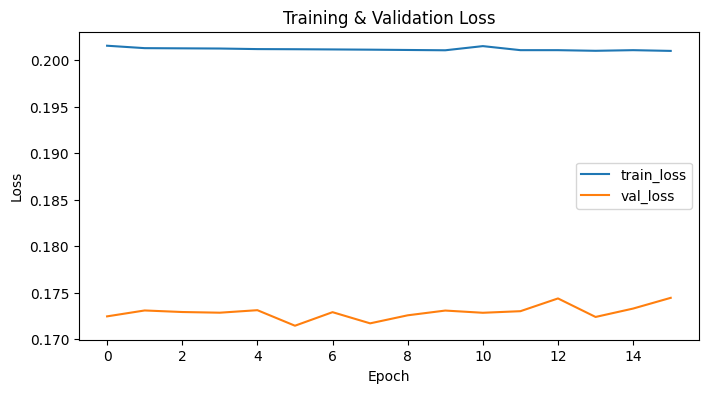

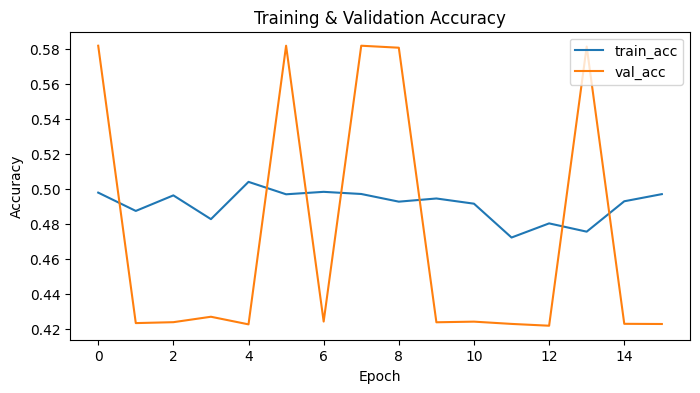

Best val_acc: 0.5818
Best val_loss: 0.1714


In [58]:
# === Этап 9: обучение LSTM-модели ===
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# ------------------------------------------------------------------
# 1. callbacks
# ------------------------------------------------------------------
es = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
rlrp = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)
cp_callback = ModelCheckpoint(
    filepath='checkpoints/lstm_best_weights.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

# ------------------------------------------------------------------
# 2. class weights (считаем на последовательностях)
# ------------------------------------------------------------------
w0 = 1.0
w1 = len(y_train_lstm[y_train_lstm == 0]) / max(1, len(y_train_lstm[y_train_lstm == 1]))
class_w = {0: w0, 1: w1}

# ------------------------------------------------------------------
# 3. обучение
# ------------------------------------------------------------------
history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    class_weight=class_w,
    callbacks=[es, rlrp, cp_callback],
    verbose=2
)

# ------------------------------------------------------------------
# 4. графики
# ------------------------------------------------------------------
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'],     label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training & Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(history.history['accuracy'],     label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title('Training & Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print(f"Best val_acc: {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss: {min(history.history['val_loss']):.4f}")


In [59]:
y_pred_proba = model.predict(X_test_lstm, verbose=0)
y_pred = (y_pred_proba >= 0.5).astype(int).ravel()

# Проверим формы
print("X_test_lstm.shape =", X_test_lstm.shape)
print("y_test_lstm.shape =", y_test_lstm.shape)
print("y_pred.shape       =", y_pred.shape)

# Посчитаем метрики
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

acc  = accuracy_score(y_test_lstm, y_pred)
prec = precision_score(y_test_lstm, y_pred)
rec  = recall_score(y_test_lstm, y_pred)
f1   = f1_score(y_test_lstm, y_pred)
cm   = confusion_matrix(y_test_lstm, y_pred)

print("=== Test Metrics ===")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}\n")
print("=== Confusion Matrix ===")
print(cm)

X_test_lstm.shape = (19344, 25, 28)
y_test_lstm.shape = (19344,)
y_pred.shape       = (19344,)
=== Test Metrics ===
Accuracy : 0.5816
Precision: 0.0000
Recall   : 0.0000
F1-score : 0.0000

=== Confusion Matrix ===
[[11250     0]
 [ 8094     0]]


/Users/a1234/Fraud/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
# Шаг 1: Настройка callback для сохранения лучших весов
from tensorflow.keras.callbacks import ModelCheckpoint
import tensorflow as tf
import os

# Создаём папку для чекпойнтов, если её ещё нет
os.makedirs("checkpoints", exist_ok=True)

# Путь для сохранения лучших весов
checkpoint_path = "checkpoints/lstm_best_weights.h5"

# Callback для сохранения только лучших весов на основе 'val_loss'
cp_callback = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',       # Следим за валидационной метрикой
    save_best_only=True,      # Сохраняем только лучшие веса
    mode='min',               # Минимизируем метрику (например, для val_loss)
    verbose=1,                # Печать, когда сохраняется
    save_freq='epoch'        # Сохраняем после каждой эпохи
)

# Шаг 2: Обучение модели с использованием этого колбэка
# рассчитываем вес редкого класса
w0 = 1.0
w1 = len(y_train_lstm[y_train_lstm == 0]) / max(1, len(y_train_lstm[y_train_lstm == 1]))
class_w = {0: w0, 1: w1}

history = model.fit(
    X_train_lstm, y_train_lstm,
    epochs=200,
    batch_size=32,
    validation_data=(X_val_lstm, y_val_lstm),
    class_weight=class_w,
    callbacks=[es, rlrp, cp_callback],
    verbose=2
)

# Шаг 3: Сохранение модели целиком и веса
import pickle
from pathlib import Path

# 1) Создаём папку для артефактов
artifacts_dir = Path("artifacts")
artifacts_dir.mkdir(exist_ok=True)

# 2) Сохраняем модель целиком (архитектура + веса)
model_path = artifacts_dir / "lstm_eth_fraud_model.h5"
model.save(str(model_path))
print(f"Модель сохранена в {model_path}")

# 3) Сохраняем scaler
scaler_path = artifacts_dir / "scaler.pkl"
with open(scaler_path, "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler сохранён в {scaler_path}")

# 4) Сохраняем список признаков (чтобы при загрузке знать порядок столбцов)
feature_list = X.columns.tolist()  # X – до разбиения, без FLAG
features_path = artifacts_dir / "features_list.pkl"
with open(features_path, "wb") as f:
    pickle.dump(feature_list, f)
print(f"Список признаков сохранён в {features_path}")

# Шаг 4: Извлечение и сохранение эмбеддингов
_ = model.predict(X_train_lstm[:1])

# Создаём модель для получения эмбеддингов (например, из первого LSTM слоя)
embedding_model = tf.keras.Model(inputs=model.input, outputs=model.layers[0].output)

# Извлекаем эмбеддинги для тренировочных и тестовых данных
embeddings_train = embedding_model.predict(X_train_lstm)
embeddings_test = embedding_model.predict(X_test_lstm)

# Сохраняем эмбеддинги
np.save("artifacts/embeddings_train.npy", embeddings_train)
np.save("artifacts/embeddings_test.npy", embeddings_test)
print(f"Эмбеддинги сохранены в 'artifacts/embeddings_train.npy' и 'artifacts/embeddings_test.npy'")

# Шаг 5: Проверка воспроизводимости (если необходимо)
# Загружаем модель и другие артефакты
model = tf.keras.models.load_model(str(artifacts_dir / "lstm_eth_fraud_model.h5"))
with open(artifacts_dir / "scaler.pkl", "rb") as f:
    scaler = pickle.load(f)
with open(artifacts_dir / "features_list.pkl", "rb") as f:
    features_list = pickle.load(f)

# Загружаем эмбеддинги (если нужно)
embeddings_train = np.load("artifacts/embeddings_train.npy")
embeddings_test = np.load("artifacts/embeddings_test.npy")

print("Эмбеддинги и модель успешно загружены для дальнейшего использования.")


NameError: name 'y_train_res' is not defined